In [1]:
using DifferentialEquations
using Plots
using LinearAlgebra

include("Chemkin.jl")

# This model doesn't work well because it combines two kinetics theories without calibration
# This self-contradicting ODE struggled to integrate, and looks weird...

#temperature (assumed constant)
T = 1200 #K
P = 10e5 #Pa

R = 8.314 # J/molK

c_tot = P / (R*T) # ideal gas law

# Initial species concentrations: N2, O2, CH4, H2O, CO2, CO, H2
species_names = ["N2", "O2", "CH4", "H2O", "CO2", "CO", "H2"]
n_s = 7

X0 = zeros(length(species_names)+1)
X0[1] = T # K
X0[2:end] = c_tot*[0.7148, 0.1901, 0.0951, 0, 0, 0, 0] # mol/m^3, 75% air 25% methane mixture

# Atomic accounting check
println("The amount of hydrogen atoms is "*string(X0[4]*4+X0[5]*2+X0[8]*2)*" moles")
println("The amount of carbon atoms is "*string(X0[4]+X0[6]+X0[7])*" moles")
println("The amount of oxygen atoms is "*string(X0[3]*2+X0[5]+X0[6]*2+X0[7])*" moles")

# Stoichiometric matrix
S = [0 -0.5 -1 0 0 1 2; 
     0 0 -1 -1 0 1 3; 
     0 -0.5 0 1 0 0 -1; 
     0 0.5 0 -1 0 0 1; 
     0 0 0 -1 1 -1 1; 
     0 0 0 1 -1 1 -1]

n_r = 6

species_dict = load_chemical_data("CHEMKIN-THERMDAT.txt")

The amount of hydrogen atoms is 38.12845802261247 moles
The amount of carbon atoms is 9.532114505653118 moles
The amount of oxygen atoms is 38.10841151471414 moles


Dict{String, Tuple{Float64, Vector{Float64}}} with 550 entries:
  "HSIC"          => (1500.0, [5.84954, 0.000762835, -9.97413e-8, -3.81159e-11,…
  "H2S"           => (1000.0, [2.88315, 0.00382783, -1.4234e-6, 2.498e-10, -1.6…
  "SIF3NHSIH3"    => (1000.0, [16.6994, 0.00778978, -8.11057e-7, -7.6502e-10, 1…
  "CLSI(CH3)2CH2" => (1500.0, [21.151, 0.00801827, -7.92425e-7, -3.29505e-10, 5…
  "GEF2"          => (1000.0, [4.76795, 0.00841094, -1.67642e-5, 1.56225e-8, -5…
  "CSICL3"        => (1500.0, [12.5054, 0.000533922, -2.58861e-7, 6.07531e-11, …
  "H2GAME"        => (600.0, [5.8316, 0.0122287, 3.03367e-7, -3.95694e-9, 1.225…
  "O2-"           => (1000.0, [3.88301, 0.000740787, -2.96178e-7, 5.7243e-11, -…
  "ASALME"        => (600.0, [7.12711, 0.00735786, 2.3008e-8, -2.2264e-9, 6.927…
  "CH2CLCHCL2"    => (1500.0, [16.1874, 0.00304768, -5.0115e-7, -1.5967e-11, 7.…
  "CHCLCCLOH"     => (1500.0, [14.1221, 0.00258376, -4.5769e-7, 5.21568e-12, 3.…
  "H2SI(CH3)CH2"  => (1500.0, [13.8883, 0.007

In [2]:
# Reaction rate function
function Arrhenius(X)
    R = 1.987204258640

    T = X[1]
    Y = X[2:end] # mol/m3

    Y1 = Y * 1e-3 # Jones & Lindstedt use kmol and m
    Y2 = Y * 1e-3 # Graven & Long use mol and liters
    
    k  = zeros(6)
    k[1] = 0.44e12 * exp(-30000 / (R * T)) #from Jones & Lindstedt 1988
    k[2] = 0.30e9 * exp(-30000 / (R * T)) #from Jones & Lindstedt 1988
    k[3] = 0.25e17 * T^-1 * exp(-40000 / (R * T)) #from Jones & Lindstedt 1988
    k[4] = 0
    k[5] = 5.0e12 * exp(-67300/ (R * T)) #from Graven & Long 1953
    k[6] = 9.5e10 * exp(-57000/ (R * T)) #from Graven & Long 1953

    
    # Reaction rates
    r = zeros(6)
    r[1] = k[1] * Y1[3]^0.5 * Y1[2]^1.25 #from Jones & Lindstedt 1988
    r[2] = k[2] * Y1[3] * Y1[4] #from Jones & Lindstedt 1988
    r[3] = k[3] * Y1[7]^0.5 * Y1[2]^2.25 * Y1[4]^-1 #from Jones & Lindstedt 1988 
    r[4] = 0
    r[5] = k[5] * Y2[6]^0.5 * Y2[4] / (1 + 1.2e4 * Y2[7]) #from Graven & Long 1953
    r[6] = k[6] * Y2[7]^0.5 * Y2[5] / (1 + 3.6e3 * Y2[6]) #from Graven & Long 1953

    r[1:3]=r[1:3] * 1e3 # kmol to mol
    r[3:6]=r[3:6] * 1e3 # /l to /m3

    return r
end

# Temperature rate of change due to reaction enthalpy
function dT(X, r)
    h0_vec = []
    cp_vec = []
    dH = sum([h0(X[1],species_dict[species_names[i]]) for i in 1:n_s]' * S' * r )
    c_p = sum(X[2:end] .* [species_cp(X[1],species_dict[species_names[i]]) for i in 1:n_s])
    dT = -dH/c_p #J/mols * molK/J
    return dT[1]
end

dT (generic function with 1 method)

In [3]:
# Derivative function for the ODE system
function f!(dX, X, p, t)
    X = max.(X, 1e-50)
    r = Arrhenius(X)
    dX[1] = dT(X,r)
    dX[2:end] = S' * r  # Species concentrations change
end

f! (generic function with 1 method)

In [4]:
# Define time span and solve the ODE problem
tend = 2.5e-6
tspan = (0.0, tend)

# Define and solve the ODE problem with tighter tolerances
problem = ODEProblem(f!, X0, tspan)
@time sol = solve(problem, alg_hints=[:stiff], saveat=1e-9, abstol = 1e-6, reltol = 1e-4)

 33.913630 seconds (596.07 M allocations: 21.700 GiB, 11.80% gc time, 18.01% compilation time)


retcode: Success
Interpolation: 1st order linear
t: 2501-element Vector{Float64}:
 0.0
 1.0e-9
 2.0e-9
 3.0000000000000004e-9
 4.0e-9
 5.0e-9
 6.0e-9
 7.000000000000001e-9
 8.0e-9
 9.000000000000001e-9
 1.0000000000000002e-8
 1.1000000000000001e-8
 1.2000000000000002e-8
 ⋮
 2.4890000000000002e-6
 2.4900000000000003e-6
 2.4910000000000004e-6
 2.492e-6
 2.493e-6
 2.494e-6
 2.4950000000000003e-6
 2.4960000000000003e-6
 2.4970000000000004e-6
 2.498e-6
 2.499e-6
 2.5e-6
u: 2501-element Vector{Vector{Float64}}:
 [1200.0, 71.64621922861038, 19.05420575735707, 9.532114505653118, 0.0, 0.0, 0.0, 0.0]
 [1200.148456504963, 71.64621922861038, 19.05258271415428, 9.53106810547194, 0.002199686224405568, 2.4469857090976255e-15, 0.0010464001811712356, -0.0001068858620582033]
 [1200.291537280661, 71.64621922861038, 19.05100050281612, 9.53002031103353, 0.004316314462286042, 1.3710336773631127e-14, 0.0020941946195702247, -0.00012792522311816718]
 [1200.431785602257, 71.64621922861038, 19.0494394995901, 9.5

3049.307896147323


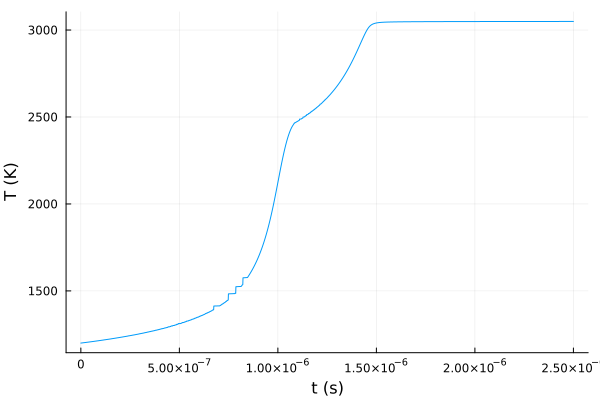

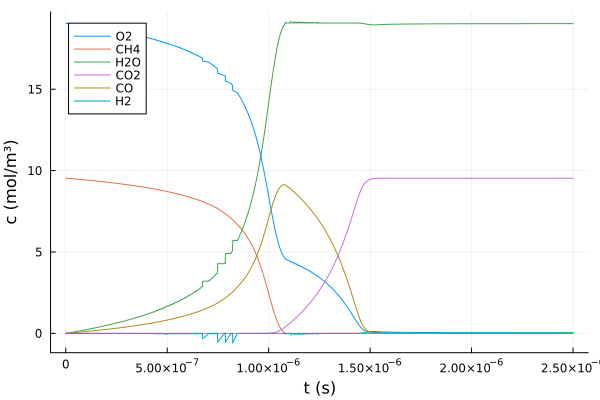

The amount of hydrogen atoms is 38.12845802261247 moles
The amount of carbon atoms is 9.532114505653118 moles
The amount of oxygen atoms is 38.10841151471414 moles


In [5]:
# Extract the solution arrays
t = sol.t
T = sol[1, :]
C = sol[3:end, :]'

println(maximum(T))

# Create a plot for the temperature
plot1 = plot(t, T, xlabel="t (s)", ylabel="T (K)", legend=false)

display(plot1)

# Create a plot for the species concentrations
plot2 = plot(t, C, xlabel="t (s)", ylabel="c (mol/m³)", label=["O2" "CH4" "H2O" "CO2" "CO" "H2"])

display(plot2)

plot(plot1, plot2, layout = (2,1))
savefig("4step")

# Atomic accounting check
println("The amount of hydrogen atoms is "*string(X0[4]*4+X0[5]*2+X0[8]*2)*" moles")
println("The amount of carbon atoms is "*string(X0[4]+X0[6]+X0[7])*" moles")
println("The amount of oxygen atoms is "*string(X0[3]*2+X0[5]+X0[6]*2+X0[7])*" moles")

In [6]:
using LinearAlgebra: norm

function compute_relaxation_time(sol; tol=1e-6)
    """
    Compute relaxation time τ for a solution `sol` of an ODEProblem.
    
    τ is defined as the time when ‖u(t) - u_steady‖ / ‖u0 - u_steady‖ ≈ 1/e.
    
    Args:
        sol: Solution object from DifferentialEquations.jl
        tol: Tolerance for checking convergence (default: 1e-6)
    
    Returns:
        τ: Relaxation time (first time when decay reaches 1/e)
        If no such time is found, returns `nothing`.
    """
    u0 = sol.prob.u0          # Initial (perturbed) state
    u_steady = sol[end]       # Equilibrium state (final value)
    Δ0 = norm(u0 - u_steady)  # Initial deviation magnitude
    
    # Handle cases where Δ0 ≈ 0 (no perturbation)
    if Δ0 < tol
        @warn "Initial state is already at equilibrium (‖Δu‖ = $Δ0). τ is undefined."
        return nothing
    end
    
    # Target deviation: Δ0 / e
    target_deviation = Δ0 / MathConstants.e
    
    # Find the first time when ‖u(t) - u_steady‖ ≤ target_deviation
    τ = nothing
    for (i, t) in enumerate(sol.t)
        Δu = norm(sol.u[i] - u_steady)
        if Δu ≤ target_deviation + tol  # Allow numerical tolerance
            τ = t
            break
        end
    end
    
    if τ === nothing
        @warn "No relaxation time found within solution timeframe. Increase `tspan`."
    end
    
    return τ
end

compute_relaxation_time(sol)

1.0480000000000002e-6